# Bab 3: Metodologi Penelitian - Data Preprocessing & Augmentation

Notebook ini mendokumentasikan tahapan persiapan data (*Data Preparation*) untuk pelatihan model *Machine Learning*.
Tahapan yang dilakukan meliputi:
1. **Pembersihan Data (Data Cleaning)**: Menyaring riwayat obrolan mentah untuk mengisolasi pesan dari pelanggan.
2. **Pelabelan Otomatis (Auto-Labeling)**: Menggunakan LLM untuk memberikan kelas/niat (*intent*) awal pada data murni.
3. **Analisis Eksploratori (EDA)**: Memvisualisasikan ketidakseimbangan kelas (*Imbalanced Data*).
4. **Data Augmentation (Generasi Data Sintetis)**: Mengatasi data *minority class* dengan teknik sintesis skenario menggunakan LLM.

In [16]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
from dotenv import load_dotenv

# Konfigurasi Visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Setup API Groq
load_dotenv('../anugerah-computer/.env')
groq_api_key = os.getenv("GROQ_API_KEY")

if not groq_api_key:
    load_dotenv('.env')
    groq_api_key = os.getenv("GROQ_API_KEY")

client = Groq(api_key=groq_api_key)

INTENTS = [
    'setuju', 'batal', 'nego_harga', 'komplain', 'klaim_garansi', 'butuh_admin',
    'tanya_status', 'info_toko', 'sapaan', 'konsultasi_kerusakan', 'tanya_estimasi_waktu', 'umum_teknis'
]

## 3.1 Data Cleaning & Penyaringan Obrolan Pelanggan
Dataset mentah `master_chat_wa.csv` berisi campuran obrolan admin dan pelanggan. 
Kita mengekstrak hanya pesan pelanggan dengan mengidentifikasi parameter `Message Id` yang berawalan `false_`.

In [17]:
print("Membaca master_chat_wa.csv...")
df_raw = pd.read_csv('master_chat_wa.csv')

# Menampilkan cuplikan data mentah
display(df_raw[['Message Id', 'Message Body', 'Formatted Name']].head())

Membaca master_chat_wa.csv...


,Message Id,Message Body,Formatted Name
0,true_211622366855206@lid_AC2292D9378555369E125...,【IMAGE】,Anda
1,true_211622366855206@lid_ACEC981E86F9304411889...,Anugerah komputer,Anda
2,false_211622366855206@lid_ACCC7B568284EA7BDECA...,Oke bg,+62 811-5670-1235
3,false_211622366855206@lid_AC0056ED0CC9DBDAF77A...,Bg berapa kemarin harganya ya,+62 811-5670-1235
4,true_211622366855206@lid_AC4ECED0F39172D7E0788...,Nnti tnya y bg blom dtg bos nya,Anda


In [18]:
# Filter: Ambil HANYA pesan pelanggan (inbound) 
df_customer = df_raw[df_raw['Message Id'].astype(str).str.startswith('false_')].copy()

# Hapus noise (gambar & pesan terlalu pendek)
df_customer = df_customer.dropna(subset=['Message Body'])
df_customer = df_customer[~df_customer['Message Body'].str.contains('【IMAGE】')]
df_customer = df_customer[df_customer['Message Body'].str.len() > 2]
df_unique = df_customer.drop_duplicates(subset=['Message Body']).copy()

print(f"Total pesan pelanggan unik dan valid: {len(df_unique)} baris.")
display(df_unique[['Message Body']].head())

Total pesan pelanggan unik dan valid: 1319 baris.


,Message Body
2,Oke bg
3,Bg berapa kemarin harganya ya
5,Okey bg
7,Tutup jam brp bg
9,Okey bg bntr lagi saya kesana


## 3.2 Pelabelan Data Asli (Ground Truth)
Melabeli sampel data asli menggunakan Large Language Model (Groq Llama-3).

In [19]:
def label_message_with_groq(text):
    prompt = f"""Anda adalah AI Data Annotator ahli bahasa Indonesia.
Tugas Anda mengklasifikasikan pesan pelanggan WhatsApp berikut ke DALAM SALAH SATU kategori ini:
{', '.join(INTENTS)}

Pesan Pelanggan: "{text}"
Keluarkan HANYA nama kategorinya saja.
"""
    try:
        completion = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0, max_tokens=10,
        )
        result = completion.choices[0].message.content.strip().lower()
        for intent in INTENTS:
            if intent in result: return intent
        return 'umum_teknis'
    except:
        return 'umum_teknis'

MAX_REAL = 200
df_sample = df_unique.sample(n=min(len(df_unique), MAX_REAL), random_state=42).copy()

real_labels = []
real_texts = []
print("Mulai melabeli data asli...")
count = 0
for idx, row in df_sample.iterrows():
    text = str(row['Message Body'])
    label = label_message_with_groq(text)
    real_labels.append(label)
    real_texts.append(text)
    count += 1
    time.sleep(0.3)

df_real = pd.DataFrame({'text': real_texts, 'intent': real_labels, 'source': 'real'})
display(df_real.head())

Mulai melabeli data asli...


,text,intent,source
0,Bang bisa minta bukti pembayaran Ndak orang ru...,tanya_status,real
1,Besok buka bg ??,info_toko,real
2,Tadi gak keburu jdi krja dulu,sapaan,real
3,malam kak,sapaan,real
4,Ndk bng soalnye ndk ngerti lepaskan e gmne,konsultasi_kerusakan,real


## 3.3 Exploratory Data Analysis (Imbalance Check)
Memvisualisasikan distribusi kelas untuk mendeteksi *imbalanced data*.

C:\Users\peno\AppData\Local\Temp\ipykernel_1188\3832785361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=dist.index, palette="viridis")


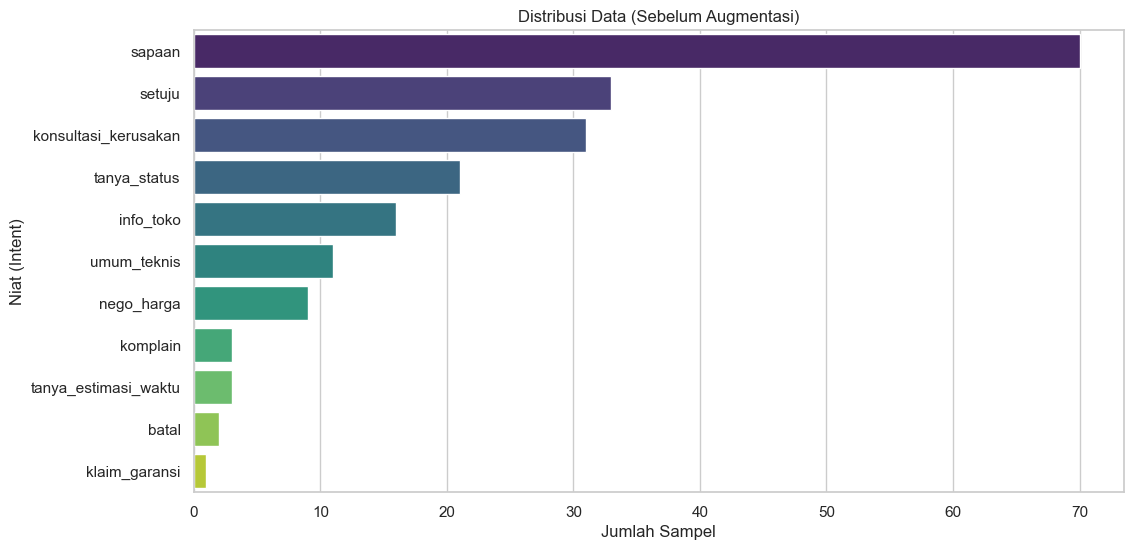

In [20]:
dist = df_real['intent'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=dist.values, y=dist.index, palette="viridis")
plt.title("Distribusi Data (Sebelum Augmentasi)")
plt.xlabel("Jumlah Sampel")
plt.ylabel("Niat (Intent)")
plt.show()

## 3.4 Synthetic Data Generation (Augmentation)
Berdasarkan grafik di atas, banyak kelas (*minority class*) memiliki jumlah sampel yang sangat sedikit.
Oleh karena itu, sesuai arahan, kita menskenariokan kalimat (Data Sintetis) agar jumlah data untuk tiap kelas minimal 40.

In [21]:
def generate_synthetic_data(intent, num_samples):
    prompt = f"""Buat {num_samples} kalimat obrolan WhatsApp pelanggan ke tempat servis komputer untuk niat/kategori: '{intent}'.
Gunakan bahasa gaul Pontianak/Indonesia sehari-hari.
Format keluaran: Cukup daftarkan kalimatnya satu per baris tanpa nomor urut.
Contoh untuk 'batal':
bang gajadi servis ya uangnya belum ada
maaf bg batal aja
laptopnya mau dipake, cancel aja
"""
    try:
        completion = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.8, max_tokens=1000,
        )
        result = completion.choices[0].message.content.strip()
        lines = [line.strip() for line in result.split('\n') if len(line.strip()) > 3]
        import re
        cleaned_lines = [re.sub(r'^\d+\.\s*|^-\s*', '', line) for line in lines]
        return cleaned_lines[:num_samples]
    except Exception as e:
        return []

MIN_SAMPLES_PER_CLASS = 40
synthetic_texts = []
synthetic_labels = []

print("Mulai Generate Data Sintetis...")
for intent in INTENTS:
    current_count = dist.get(intent, 0)
    if current_count < MIN_SAMPLES_PER_CLASS:
        needed = MIN_SAMPLES_PER_CLASS - current_count
        new_sentences = generate_synthetic_data(intent, needed)
        for s in new_sentences:
            synthetic_texts.append(s)
            synthetic_labels.append(intent)

df_synth = pd.DataFrame({'text': synthetic_texts, 'intent': synthetic_labels, 'source': 'synthetic'})
print(f"Berhasil menghasilkan {len(df_synth)} data sintetis.")

Mulai Generate Data Sintetis...
Berhasil menghasilkan 299 data sintetis.


## 3.5 Penggabungan dan Visualisasi Akhir
Menggabungkan data asli dan sintetis, kemudian mengekspornya sebagai `dataset_labeled.csv`.

,text,intent,source
0,Kira-kira servisnya butuh waktu berapa lama?,tanya_estimasi_waktu,synthetic
1,Ok otw,sapaan,real
2,"batal servis komputer, mohon maaf",batal,synthetic
3,nanti sore saya ambil laptop nya,tanya_status,real
4,"gak jadi servis komputer, udah gak ada waktu",batal,synthetic


C:\Users\peno\AppData\Local\Temp\ipykernel_1188\3038002378.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_final.values, y=dist_final.index, palette="mako")


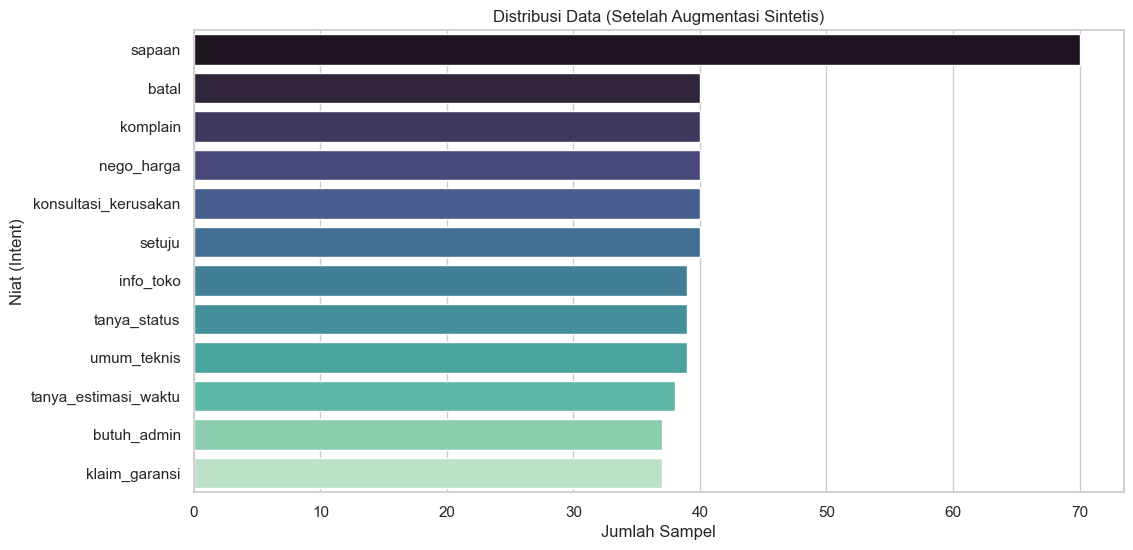

In [22]:
df_final = pd.concat([df_real, df_synth], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Simpan
df_final.to_csv('dataset_labeled.csv', index=False)
display(df_final.head())

dist_final = df_final['intent'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=dist_final.values, y=dist_final.index, palette="mako")
plt.title("Distribusi Data (Setelah Augmentasi Sintetis)")
plt.xlabel("Jumlah Sampel")
plt.ylabel("Niat (Intent)")
plt.show()